In [1]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBRegressor

# Load trained XGBoost model
model = joblib.load("receipt_forecast_model_xgb.pkl")


In [2]:
# Load and preprocess data
data_daily = pd.read_csv("data_daily.csv")
data_daily['# Date'] = pd.to_datetime(data_daily['# Date'])
data_monthly = data_daily.groupby(data_daily['# Date'].dt.to_period("M"))['Receipt_Count'].sum().reset_index()
data_monthly.columns = ['Month', 'Receipt_Count']
data_monthly['Month'] = data_monthly['Month'].astype(str)

# Normalization parameters (save from training)
max_val = data_monthly['Receipt_Count'].max()
min_val = data_monthly['Receipt_Count'].min()
data_normalized = (data_monthly['Receipt_Count'] - min_val) / (max_val - min_val)

In [3]:
data_normalized

0     0.185766
1     0.000000
2     0.317801
3     0.340447
4     0.479544
5     0.451796
6     0.608824
7     0.710778
8     0.679670
9     0.844481
10    0.845816
11    1.000000
Name: Receipt_Count, dtype: float64

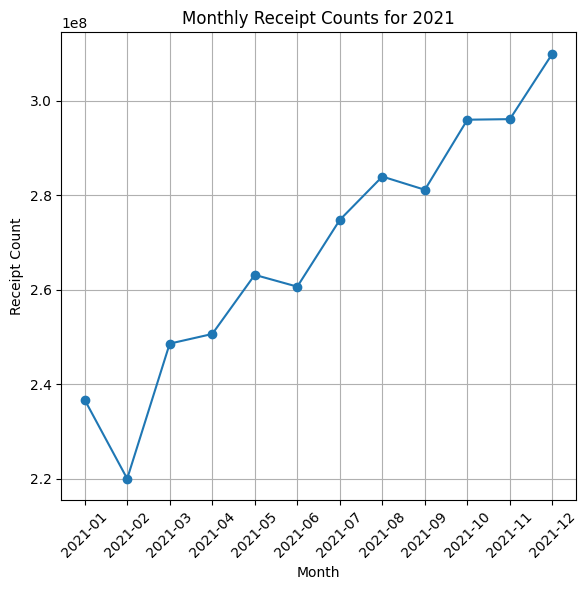

In [4]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(data_monthly['Month'], data_monthly['Receipt_Count'], marker='o', linestyle='-')
ax.set_title('Monthly Receipt Counts for 2021')
ax.set_xlabel('Month')
ax.set_ylabel('Receipt Count')
ax.grid(True)
plt.setp(ax.get_xticklabels(), rotation=45)
fig.tight_layout()


In [5]:
month_dict = {
    "January" : 1, "February":2 , "March":3 , "April":4, "May":5, "June":6,
    "July":7, "August":8, "September":9, "October":10, "November":11, "December":12
}

def get_key(dictionary, target_value):
    return [key for key, value in dictionary.items() if value == target_value][0]

In [6]:
 data_normalized

0     0.185766
1     0.000000
2     0.317801
3     0.340447
4     0.479544
5     0.451796
6     0.608824
7     0.710778
8     0.679670
9     0.844481
10    0.845816
11    1.000000
Name: Receipt_Count, dtype: float64

In [7]:
forecast = data_normalized[-3:].tolist()

In [8]:
forecast

[0.8444812971827774, 0.8458156318445028, 1.0]

In [9]:
month = "November"

# Use last 3 normalized values as initial input
forecast = data_normalized[-3:].tolist()

for _ in range(month_dict[month]):
    X = np.array(forecast[-3:]).reshape(1, -1)  # use last 3 values as input
    next_val = model.predict(X)[0]
    forecast.append(next_val)

In [10]:
forecast

[0.8444812971827774,
 0.8458156318445028,
 1.0,
 0.990785,
 0.990785,
 0.990785,
 0.990785,
 0.990785,
 0.990785,
 0.990785,
 0.990785,
 0.990785,
 0.990785,
 0.990785]

In [11]:

forecasted_values = forecast[-month_dict[month]:]
forecast_denorm = np.array(forecasted_values) * (max_val - min_val) + min_val

In [12]:
forecast_denorm

array([3.09120115e+08, 3.09120115e+08, 3.09120115e+08, 3.09120115e+08,
       3.09120115e+08, 3.09120115e+08, 3.09120115e+08, 3.09120115e+08,
       3.09120115e+08, 3.09120115e+08, 3.09120115e+08])

In [13]:
for i, value in enumerate(forecast_denorm):
    print(f"{get_key(month_dict, i+1)}'s receipt count = {value:.0f}")

January's receipt count = 309120115
February's receipt count = 309120115
March's receipt count = 309120115
April's receipt count = 309120115
May's receipt count = 309120115
June's receipt count = 309120115
July's receipt count = 309120115
August's receipt count = 309120115
September's receipt count = 309120115
October's receipt count = 309120115
November's receipt count = 309120115
